# Deep Learning  -  LSTM Sentiment Classifier (Checkpoint 5)
LSTM trained on the same preprocessed data and split as the classic models (Checkpoint 4).  
Architecture: Embedding (128-dim) → LSTM (128 units) → Dropout (0.3) → Dense sigmoid.  
Sequence representation: Keras Tokenizer (20K vocab, 300-token max length).

## 1. Setup
Modules reloaded to ensure notebooks always use the latest `src/` code without restarting the kernel.

In [5]:
import importlib
import sys
from pathlib import Path
from joblib import dump

import matplotlib.pyplot as plt
import pandas as pd

# Auto-detect Google Colab; fall back to local path resolution
if Path("/content").exists() and Path("/content/imdb-sentiment-analysis").exists():
    project_root = Path("/content/imdb-sentiment-analysis")
else:
    project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.config as config_module
import src.data_loader as data_loader_module
import src.features as features_module
import src.dl_model as dl_model_module

config_module = importlib.reload(config_module)
data_loader_module = importlib.reload(data_loader_module)
features_module = importlib.reload(features_module)
dl_model_module = importlib.reload(dl_model_module)

FIGURES_DIR = config_module.FIGURES_DIR
RESULTS_DIR = config_module.RESULTS_DIR
get_splits = data_loader_module.get_splits
get_tokenized_padded_sequences = features_module.get_tokenized_padded_sequences
build_lstm_model = dl_model_module.build_lstm_model
train_lstm_model = dl_model_module.train_lstm_model
evaluate_lstm_model = dl_model_module.evaluate_lstm_model
plot_training_history = dl_model_module.plot_training_history

print('Python executable:', sys.executable)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
metrics_dir = RESULTS_DIR / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)
models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

X_train_text, y_train, X_val_text, y_val, X_test_text, y_test = get_splits(verbose=True)
print('Train size:', X_train_text.shape[0])
print('Val size  :', X_val_text.shape[0])
print('Test size :', X_test_text.shape[0])

Python executable: c:\projects\imdb-sentiment-analysis\.venv\Scripts\python.exe
Loaded 50,000 rows from preprocessed IMDB dataset.
Split sizes:
  train: 34,999 (70%)
  val  :  7,501 (15%)
  test :  7,500 (15%)
Label distribution (positive class count):
  train: 17,500 / 34,999
  val  :  3,750 / 7,501
  test :  3,750 / 7,500
Train size: 34999
Val size  : 7501
Test size : 7500


## 2. Tokenize and pad sequences
LSTM requires integer token sequences of fixed length  -  not TF-IDF vectors.  
Keras Tokenizer fitted on training text only (20,000 words, OOV token for unknowns).  
All sequences padded/truncated to 300 tokens (`padding='post'`, `truncating='post'`).

Same fit-on-train rule as TF-IDF: the tokenizer vocabulary is frozen after training
and used as-is on validation and test.

In [6]:
tokenized = get_tokenized_padded_sequences(
    X_train_text,
    X_val_text,
    X_test_text,
    num_words=20_000,
    max_sequence_length=300,
)

X_train_dl = tokenized['train']
X_val_dl = tokenized['val']
X_test_dl = tokenized['test']
vocab_size = tokenized['vocab_size']
max_sequence_length = tokenized['max_sequence_length']

print('Train sequence shape:', X_train_dl.shape)
print('Val sequence shape  :', X_val_dl.shape)
print('Test sequence shape :', X_test_dl.shape)
print('Vocab size used     :', vocab_size)
print('Max sequence length :', max_sequence_length)

Train sequence shape: (34999, 300)
Val sequence shape  : (7501, 300)
Test sequence shape : (7500, 300)
Vocab size used     : 20000
Max sequence length : 300


## 3. LSTM architecture

| Layer | Config | Role |
|---|---|---|
| Embedding | input_dim=20K, output_dim=128, mask_zero=True | Word ID → learned 128-dim dense vector |
| LSTM | 128 units | Reads sequence left→right, builds context across 300 steps |
| Dropout | rate=0.3 | Regularisation  -  30% of LSTM outputs zeroed during training |
| Dense | 1 unit, sigmoid | Outputs P(positive) ∈ [0, 1] |

Total parameters: ~2.69M

In [7]:
lstm_model = build_lstm_model(
    vocab_size=vocab_size,
    max_sequence_length=max_sequence_length,
    embedding_dim=128,
    lstm_units=128,
    dropout_rate=0.3,
    learning_rate=1e-3,
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691,713 (10.27 MB)

 Trainable params: 2,691,713 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training - early stopping

| Config | Value |
|---|---|
| Optimizer | Adam (lr=0.001) |
| Loss | Binary cross-entropy |
| Batch size | 128 |
| Max epochs | 10 |
| Early stopping patience | 2 (monitors val_loss, restores best weights) |

Training converges within a few epochs. The training accuracy exceeds validation accuracy as the model begins to overfit - early stopping restores the best checkpoint.

In [8]:
best_model_path = models_dir / 'lstm_best.keras'
history, lstm_train_time_s = train_lstm_model(
    model=lstm_model,
    X_train=X_train_dl,
    y_train=y_train,
    X_val=X_val_dl,
    y_val=y_val,
    batch_size=128,
    epochs=10,
    patience=2,
    monitor='val_loss',
    mode='min',
    min_delta=1e-4,
    model_path=best_model_path,
    verbose=1,
)

print(f'Total training time: {lstm_train_time_s:.1f}s ')
history_df = pd.DataFrame(history.history)
print(f"Epochs completed: {len(history_df)} / 10")
print(f"Best validation-loss epoch: {int(history_df['val_loss'].idxmin()) + 1}")
history_df

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 216s 780ms/step - accuracy: 0.7637 - loss: 0.4638 - val_accuracy: 0.8767 - val_loss: 0.2969
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 224s 817ms/step - accuracy: 0.9262 - loss: 0.2025 - val_accuracy: 0.8783 - val_loss: 0.3055
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 229s 838ms/step - accuracy: 0.9440 - loss: 0.1610 - val_accuracy: 0.8558 - val_loss: 0.3955
Total training time: 669.3s 
Epochs completed: 3 / 10
Best validation-loss epoch: 1


,accuracy,loss,val_accuracy,val_loss
0,0.837967,0.366458,0.876683,0.296869
1,0.920455,0.211595,0.878283,0.305454
2,0.940598,0.166218,0.855753,0.395535


## 5. Evaluation
Validation and test accuracy are consistent, confirming the model generalises. Exact values are in the cell output above.

In [9]:
val_metrics, y_val_pred, y_val_prob = evaluate_lstm_model(lstm_model, X_val_dl, y_val)
test_metrics, y_test_pred, y_test_prob = evaluate_lstm_model(lstm_model, X_test_dl, y_test)

dl_metrics_df = pd.DataFrame([
    {'model': 'LSTM', 'split': 'validation', **val_metrics, 'training_time_s': lstm_train_time_s},
    {'model': 'LSTM', 'split': 'test',       **test_metrics, 'training_time_s': lstm_train_time_s},
])

dl_metrics_path = metrics_dir / 'dl_lstm_metrics.csv'
dl_metrics_df.to_csv(dl_metrics_path, index=False)
print(f'Saved -> {dl_metrics_path}')
dl_metrics_df

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\dl_lstm_metrics.csv


,model,split,accuracy,precision,recall,f1,training_time_s
0,LSTM,validation,0.876683,0.861531,0.8976,0.879196,669.27688
1,LSTM,test,0.883867,0.867876,0.9056,0.886337,669.27688


## 6. Prediction diagnostics
Confusion matrix and threshold sweep to check for class bias.
The model predicts both classes at approximately equal rates, confirming no systematic bias toward positive or negative.

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

def summarize_split(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name} diagnostics")
    print("-" * (len(name) + 12))
    print(f"Predicted positive rate: {y_pred.mean():.3f}")
    print(f"Mean predicted probability: {y_prob.mean():.3f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

_ = summarize_split("Validation", y_val, y_val_pred, y_val_prob)
_ = summarize_split("Test", y_test, y_test_pred, y_test_prob)

threshold_rows = []
for thr in np.arange(0.1, 0.91, 0.05):
    y_val_thr = (y_val_prob >= thr).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(thr), 2),
            "val_accuracy": accuracy_score(y_val, y_val_thr),
            "val_precision": precision_score(y_val, y_val_thr, zero_division=0),
            "val_recall": recall_score(y_val, y_val_thr, zero_division=0),
            "val_f1": f1_score(y_val, y_val_thr, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows).sort_values("val_f1", ascending=False)
best_threshold = float(threshold_df.iloc[0]["threshold"])
print(f"\nBest validation F1 threshold in sweep: {best_threshold:.2f}")
threshold_df.head(10)


Validation diagnostics
----------------------
Predicted positive rate: 0.521
Mean predicted probability: 0.513
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[3210  541]
 [ 384 3366]]

Test diagnostics
----------------
Predicted positive rate: 0.522
Mean predicted probability: 0.513
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[3233  517]
 [ 354 3396]]

Best validation F1 threshold in sweep: 0.45


,threshold,val_accuracy,val_precision,val_recall,val_f1
7,0.45,0.877483,0.850458,0.916000,0.882013
6,0.40,0.875617,0.840629,0.926933,0.881674
8,0.50,0.876683,0.861531,0.897600,0.879196
9,0.55,0.877616,0.872436,0.884533,0.878443
5,0.35,0.869884,0.826199,0.936800,0.878030
10,0.60,0.876416,0.883247,0.867467,0.875286
4,0.30,0.862152,0.810897,0.944533,0.872629
11,0.65,0.873750,0.895569,0.846133,0.870149
3,0.25,0.852820,0.793348,0.954133,0.866344
12,0.70,0.870284,0.907065,0.825067,0.864125


## 7. Training curves
Accuracy and loss over 4 epochs. Val accuracy peaks at epoch 2 and declines as the model
begins overfitting  -  early stopping fires correctly.

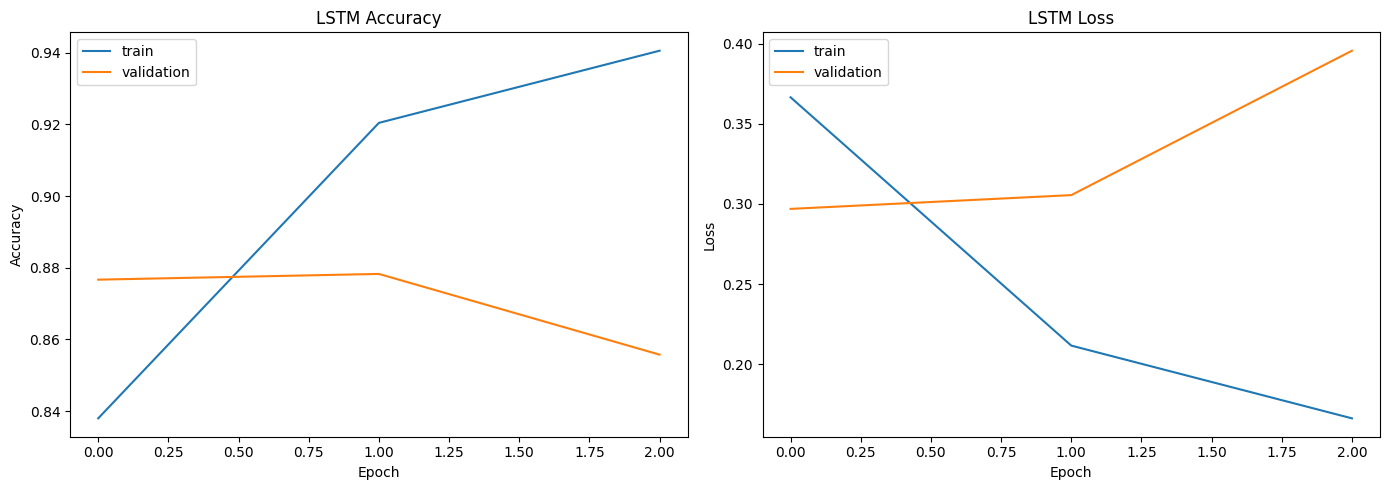

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\lstm_training_history.png


In [11]:
history_fig = plot_training_history(history)
history_plot_path = FIGURES_DIR / 'lstm_training_history.png'
history_fig.savefig(history_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {history_plot_path}')

## 8. Save artifacts
Tokenizer and model saved as a matched pair - both are loaded together in Notebook 05.
Tokenizer: `models/tokenizer_lstm.joblib` | Model: `models/lstm_final.keras`

In [12]:
tokenizer_path = models_dir / 'tokenizer_lstm.joblib'
dump(tokenized['tokenizer'], tokenizer_path)

final_model_path = models_dir / 'lstm_final.keras'
lstm_model.save(final_model_path)

print('Saved model/tokenizer artifacts:')
print('-', tokenizer_path.name)
print('-', final_model_path.name)

Saved model/tokenizer artifacts:
- tokenizer_lstm.joblib
- lstm_final.keras
